# **Sources PSFs Analysis | Baseline VS MaskShift**

In [1]:
from pathlib import Path
from typing import Any

import numpy as np
from numpy.typing import NDArray

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask
import darksun as ds

from IROSrec.handle import config_dirpaths
import imgmaker as mgm

ds.show.set_figures_darkbkg()

In [ ]:
MASK_FITS: str = "mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "CameraGeometry"

DATA_FITS_bline: str = "baseline_2-50keV_1ks"
RUN_ID_bline: str = 'baseline_wcxb'

DATA_FITS_mshift: str = "mask_Z2arcmin_2-50keV_1ks"
RUN_ID_mshift: str = 'mask_Z2arcmin'

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

VIGNETTING: bool = True
PSFY: bool = mgm.config_psfy_flag(DATASET)

E_min, E_max = 2.0, 50.0           # [keV]
# exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = [
#         CoordEquatorial(318.950871147977, -51.1920260999562),   # s0
#         CoordEquatorial(296.376333558386, 5.25424886863538),    # s1
#         CoordEquatorial(236.423666441614, 5.25424886863538),    # s2
#         CoordEquatorial(213.849128852023, -51.1920260999562),   # s3
#         CoordEquatorial(286.170341181402, -42.2037736309785),   # s4
#         CoordEquatorial(281.331753525598, -13.4867719837475),   # s5
#         CoordEquatorial(251.468246474402, -13.4867719837475),   # s6
#         CoordEquatorial(246.629658818598, -42.2037736309785),   # s7
#         CoordEquatorial(266.4, -28.94),                         # s8
#     ]
exclude_coords: CoordEquatorial | list[CoordEquatorial] | None = None

In [3]:
MASK_PATH, SIMUL_DATA_PATH_bline, SAVE_PATH_bline = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS_bline,
    runID=RUN_ID_bline,
)
_, SIMUL_DATA_PATH_mshift, SAVE_PATH_mshift = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS_mshift,
    runID=RUN_ID_mshift,
)
# OUT_RESULTS_PATH = '/home/edoardo/Desktop'
OUT_RESULTS_PATH = '/mnt/d/PhD_AASS/Coding/Images_fits'

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

sdlA_bline = ds.get_data(
    SIMUL_DATA_PATH_bline + f'{ID_CAMERA_A}/{DATA_FITS_bline}_{ID_CAMERA_A}_{DATASET}.fits',
    E_min=E_min, E_max=E_max, coords=exclude_coords,
)
sdlA_mshift = ds.get_data(
    SIMUL_DATA_PATH_mshift + f'{ID_CAMERA_A}/{DATA_FITS_mshift}_{ID_CAMERA_A}_{DATASET}.fits',
    E_min=E_min, E_max=E_max, coords=exclude_coords,
)

logA_bline, _ = ds.load_database(f"{SAVE_PATH_bline}/OUT_{RUN_ID_bline}_srcDB.fits")
logA_mshift, _ = ds.load_database(f"{SAVE_PATH_mshift}/OUT_{RUN_ID_mshift}_srcDB.fits")
cu_map = mgm.get_srcmap_for_unit(logA_bline.log['ID'], logA_mshift.log['ID'])

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [4]:
# from astropy.io import fits

# def load_fits_img(filepath: Path, *ext: int) -> list[NDArray]:
#     """Open FITS and retrieve ImageHDU data following given `ext` order."""
#     objs: list[NDArray] = []
#     with fits.open(filepath) as hdu:
#         for e in ext: objs.append(hdu[e].data)
#     return objs[0] if len(ext) == 1 else objs

# skymap_bline, snrmap_bline = ds.load_sky(f"{SAVE_PATH_bline}/SIMUL_sky.fits")
# skymap_mshift, snrmap_mshift = ds.load_sky(f"{SAVE_PATH_mshift}/SIMUL_sky.fits")



from bloodmoon.mask import count, decode

d_bline: NDArray = count(wfm, sdlA_bline.DLdata)[0]
skymap_bline: NDArray = decode(wfm, d_bline)

d_mshift: NDArray = count(wfm, sdlA_mshift.DLdata)[0]
skymap_mshift: NDArray = decode(wfm, d_mshift)

In [5]:
def custom_slices_plot(
    camera: CodedMaskCamera,
    sky: NDArray | tuple[NDArray],
    pos: tuple[int, int],
    crp: tuple[int, int],
    *,
    title_prefix: str | None = None,
    ylabel: str | None = None,
    ylim_xslice: tuple[Any, Any] | None = None,
    ylim_yslice: tuple[Any, Any] | None = None,
    labels: str | tuple[str | None] | None = None,
    color: str | tuple[str] | None = None,
    save_to: str | Path | None = None,
    **kwargs: Any,
) -> None:
    """
    Plots horizontal and vertical slices of 2D data arrays centered at a given position.
    """
    def phase(x: NDArray) -> NDArray:
        """Centers x-axis values around zero."""
        return np.arange(len(x) + 1) - len(x) // 2 - 0.5
    
    cropped = tuple(
        ds.crop(s, pos, crp, strict=False) for s in (
            (sky,) if isinstance(sky, np.ndarray) else sky
        )
    )
    xslice, yslice = zip(
        *tuple((c[crp[0], :], c[:, crp[1]]) for c in cropped)
    )
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    kws = {
        'ylabel': ylabel or 'counts [ph]',
        'labels': labels,
        'style': 'stairs',
        'color': color,
    }
    dmapx = ds.map4plot(
        arrs=xslice,
        title=f"{title_prefix_}" + "PSF Fine Direction",
        xlabel='$\\theta_{fine}$ [arcmin]',
        x=map(lambda x: dtx * phase(x), xslice),
        ylim=ylim_xslice or (None, None),
        **kws,
    )
    dmapy = ds.map4plot(
        arrs=yslice,
        title=f"{title_prefix_}" + "PSF Coarse Direction",
        xlabel='$\\theta_{coarse}$ [deg]',
        x=map(lambda y: dty * phase(y) / 60, yslice),
        ylim=ylim_yslice or (None, None),
        **kws,
    )
    ds.plot(
        dmaps=(dmapx, dmapy),
        ncols=2,
        save_to=save_to,
        **kwargs,
    )
    return

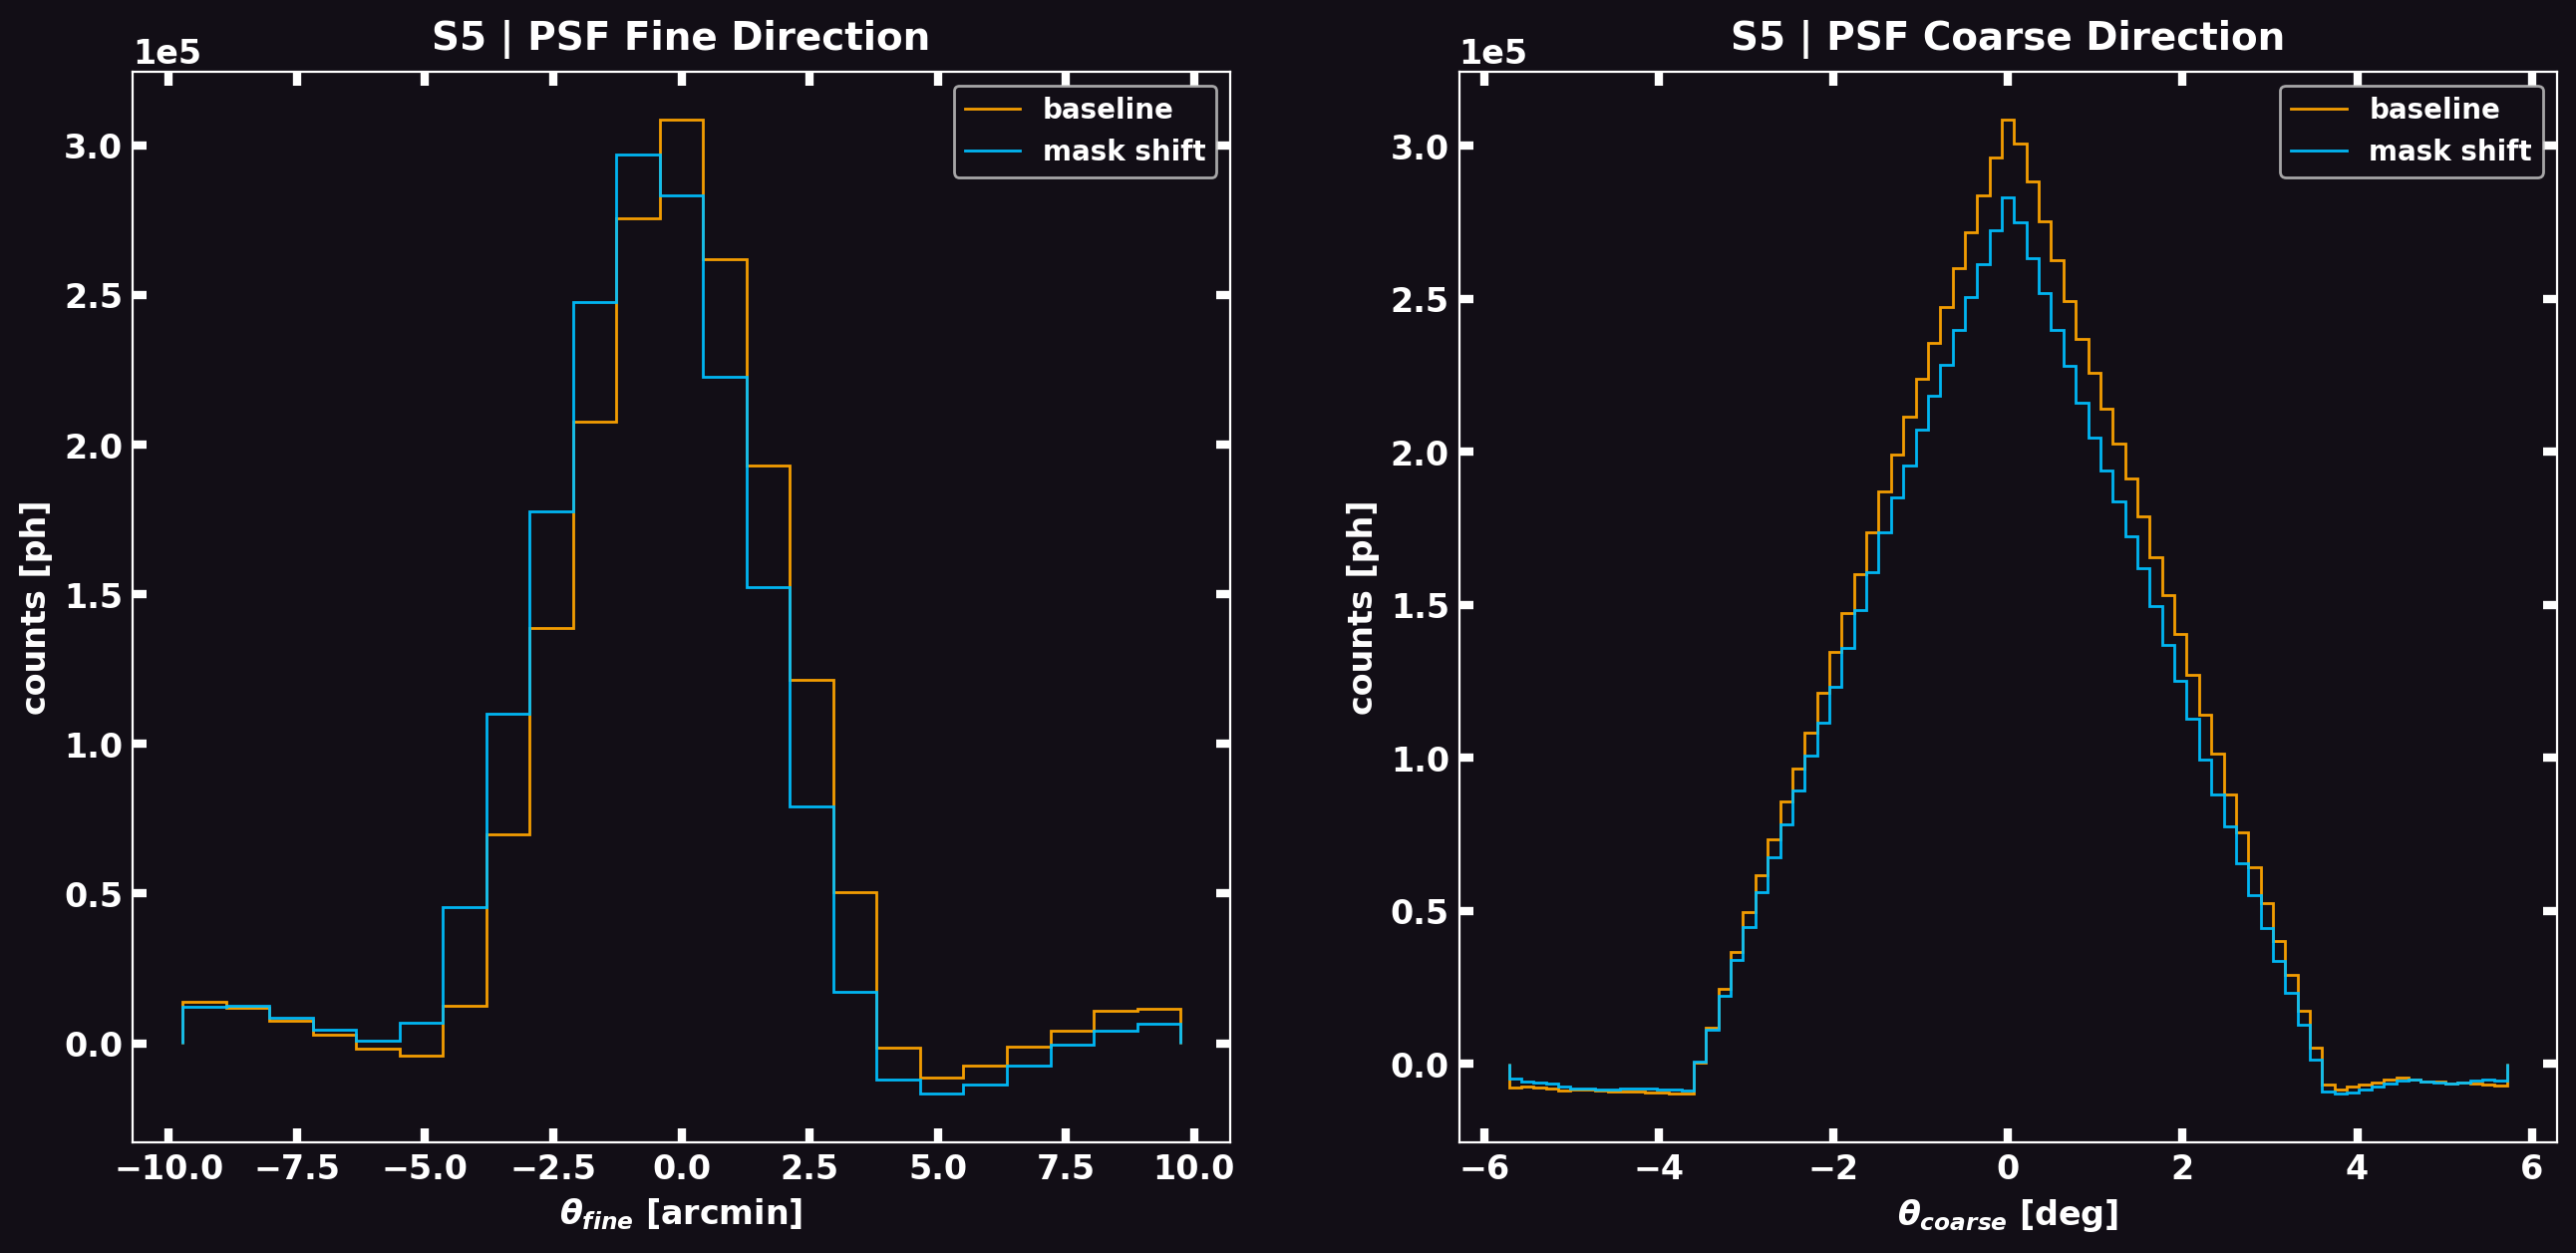

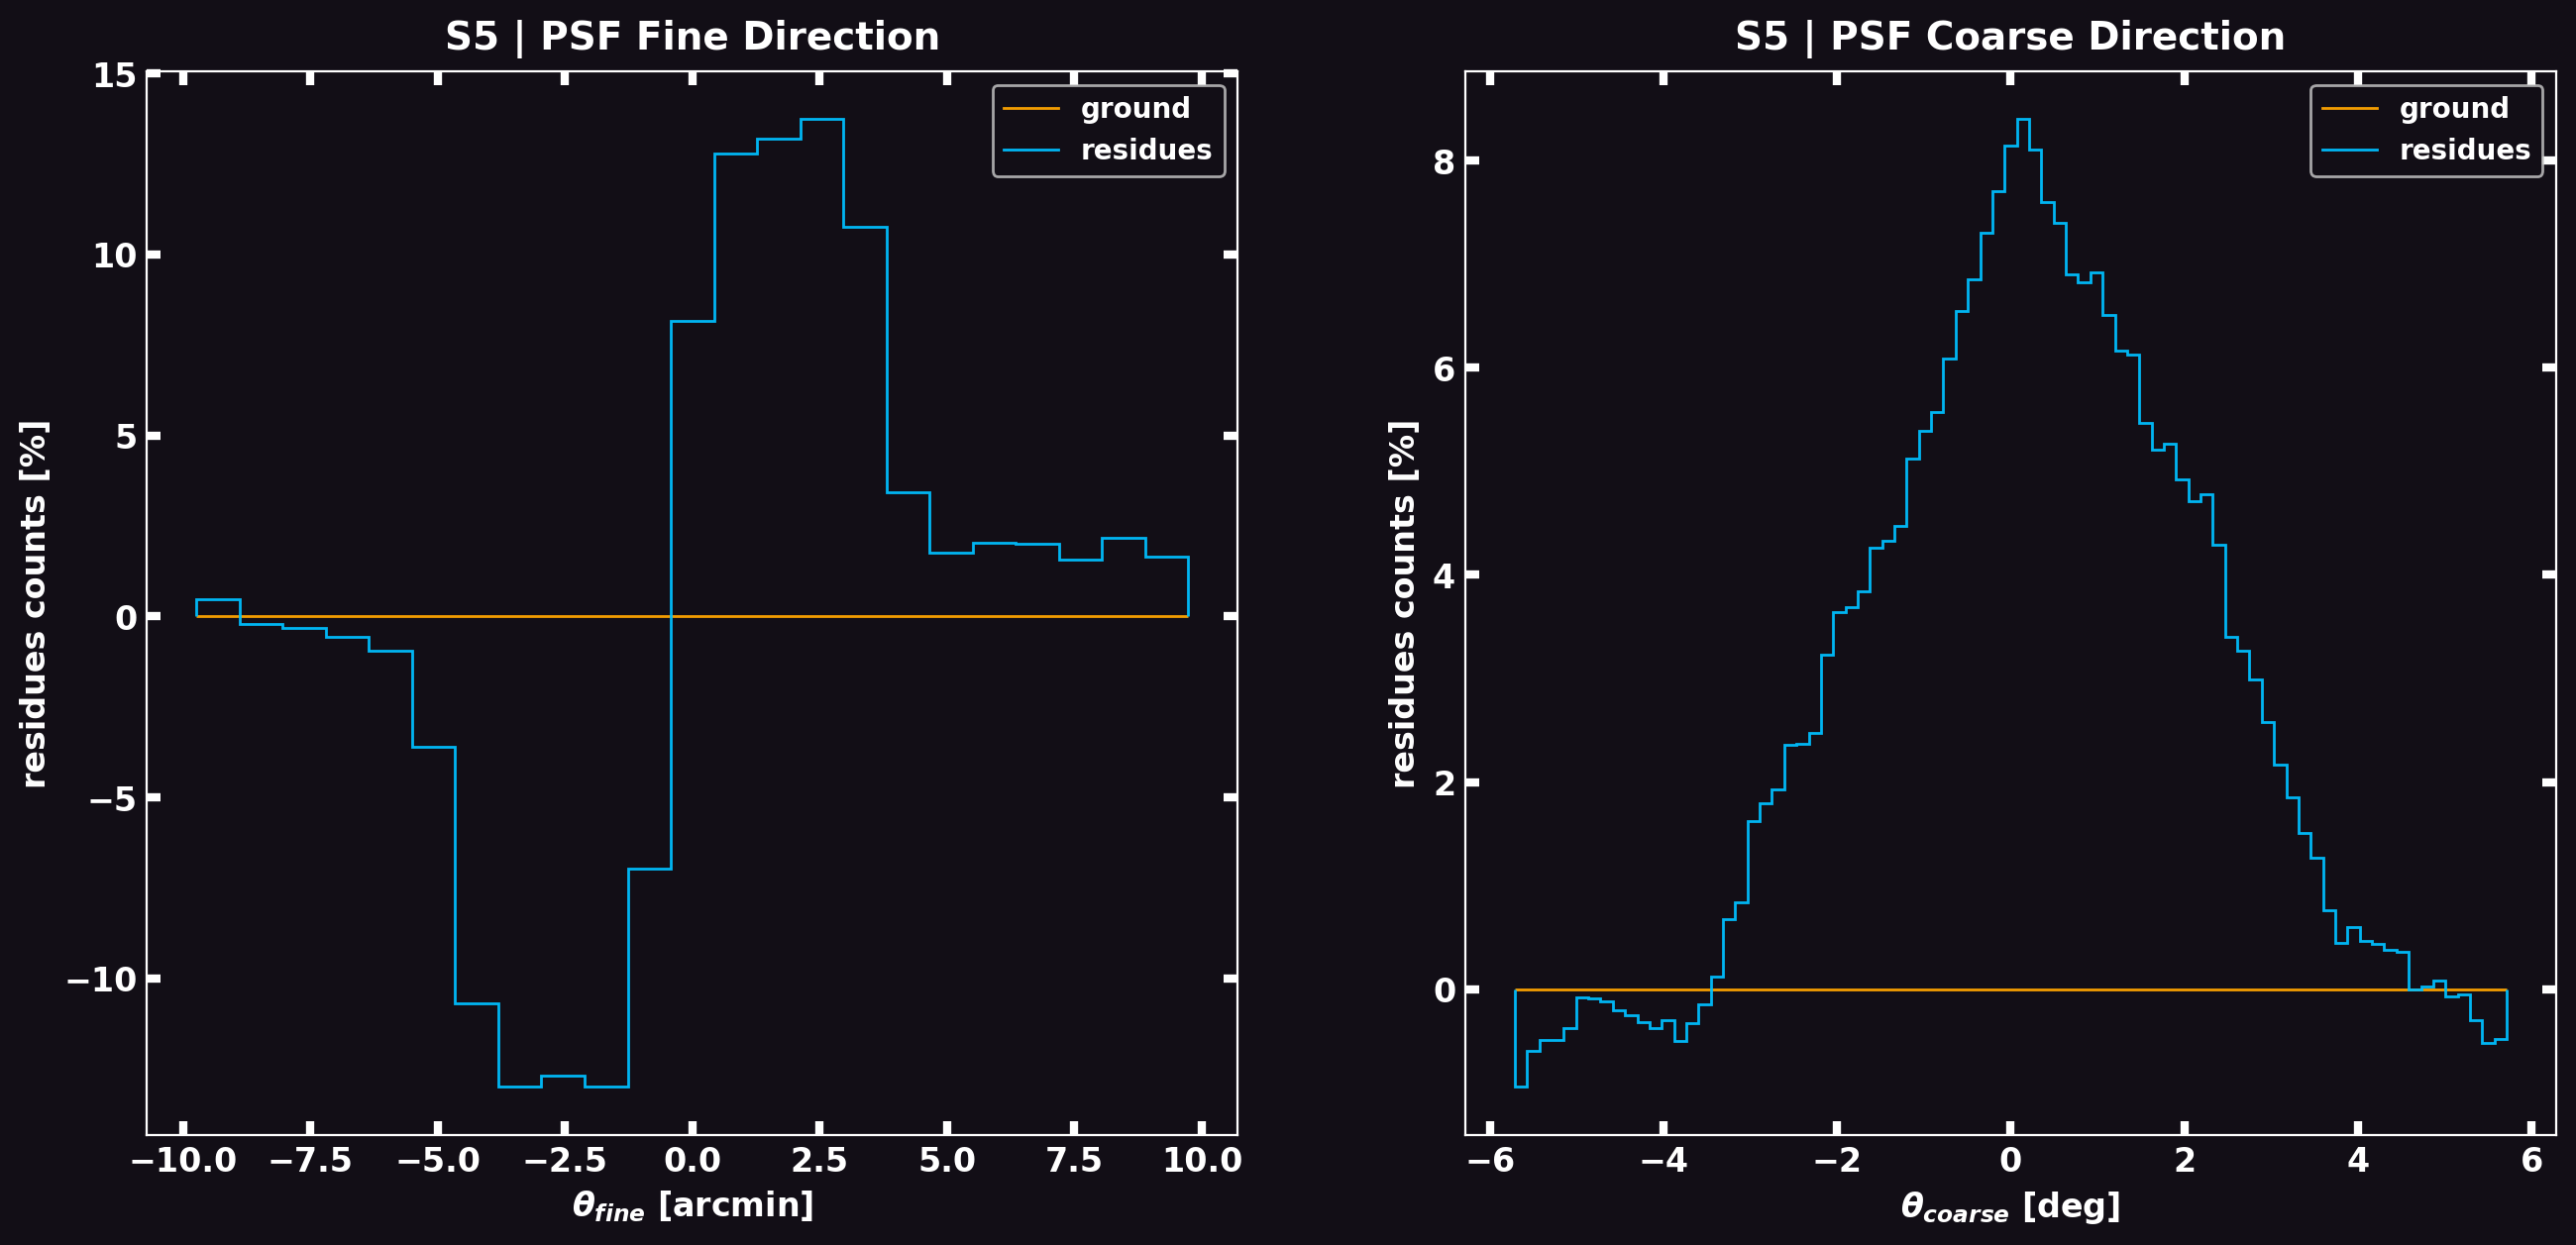

In [18]:
SRC_ID: str = 's5'


IDX: int = int(np.argwhere(cu_map.common == SRC_ID)[0, 0])
KWS = {
    'pos': (np.array(logA_bline.log['y'])[cu_map.idx_a][IDX], np.array(logA_bline.log['x'])[cu_map.idx_a][IDX]),
    'crp': (40 * UPS_Y, 2 * UPS_X + 1),
    'title_prefix': SRC_ID.upper(),
    'color': ('Orange', 'DeepSkyBlue'),
}
residues = (skymap_bline - skymap_mshift) * 100 / skymap_bline[KWS['pos']]
# ratio = np.clip(skymap_mshift, a_min=1, a_max=None) / np.clip(skymap_bline, a_min=1, a_max=None)

custom_slices_plot(
    camera=wfm,
    sky=(skymap_bline, skymap_mshift),
    labels=('baseline', 'mask shift'),
    # save_to=f'{OUT_RESULTS_PATH}/psf_slices_{E_min}-{E_max}keV.pdf',
    **KWS,
)
custom_slices_plot(
    camera=wfm,
    sky=(np.zeros_like(residues), residues),
    labels=('ground', 'residues'),
    ylabel=r'residues counts [%]',
    # save_to=f'{OUT_RESULTS_PATH}/psf_slices_res_{E_min}-{E_max}keV.pdf',
    **KWS,
)
# custom_slices_plot(
#     camera=wfm,
#     sky=(np.ones_like(ratio), ratio),
#     labels=('ground', 'ratio'),
#     ylabel=r'ratio',
#     # save_to=f'{OUT_RESULTS_PATH}/psf_slices_ratio_{E_min}-{E_max}keV.pdf',
#     **KWS,
# )

In [19]:
import matplotlib.pyplot as plt
from darksun.show import DSPlot, export_pltparams

def custom_PSF_hmap(
    camera: CodedMaskCamera,
    psf: NDArray,
    residues: NDArray,
    xticks: NDArray,
    yticks: NDArray,
    title_prefix: str | None = None,
    save_to: str | Path | None = None,
) -> None:
    """
    Plots the true PSF of given source and residues wrt `bm` template from IROS.
    """    
    PLOTPARAMS = export_pltparams()
    n, m = psf.shape
    dtx, dty = ds.pixels_angular_resolution(camera, verbose=False)
    _yticks_lbl, _xticks_lbl = dty / 60 * (yticks - n // 2), dtx * (xticks - m // 2)
    yticks_lbl, xticks_lbl = map(lambda arr: [float(f'{a:.1f}') for a in arr], (_yticks_lbl, _xticks_lbl))
    aspect = 2 * KWS['crp'][1] / KWS['crp'][0]
    title_prefix_ = f'{title_prefix} | ' if title_prefix is not None else ''

    # res_ = residues * 100 / psf[(n - 1) // 2, (m - 1) // 2]
    valres = max(abs(residues.min()), abs(residues.max()))

    dsp = DSPlot(2, 1)
    fig, axs = dsp.config_subplots(size=6, ptype='image')
    fig.subplots_adjust(wspace=-1e-1)

    # - IMG axis 0  |  PSF
    dsp.config_labels(axs[0], f'{title_prefix_}PSF', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[0].imshow(psf, origin=PLOTPARAMS['cbar_origin'], cmap='gist_heat', aspect=aspect)
    cbar = fig.colorbar(
        img, ax=axs[0], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'counts [ph]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )

    # - IMG axis 1  |  Residues (true-template)
    dsp.config_labels(axs[1], f'{title_prefix_}Residues', '$\\theta_{fine}$ [arcmin]', '$\\theta_{coarse}$ [deg]')
    img = axs[1].imshow(
        residues, origin=PLOTPARAMS['cbar_origin'], cmap='viridis', aspect=aspect, vmin=-valres, vmax=valres,
    )
    cbar = fig.colorbar(
        img, ax=axs[1], location='right', shrink=PLOTPARAMS['cbar_shrink'],
        pad=PLOTPARAMS[f'cbar_pad_right'],
    )
    cbar.ax.tick_params(labelsize=PLOTPARAMS['cbar_ticks_ls'])
    cbar.set_label(
        'residues counts [%]', fontsize=PLOTPARAMS['cbar_label_fs'], fontweight=PLOTPARAMS['cbar_label_fw'],
    )
    
    for ax in axs:
        ax.xaxis.set_ticks_position('both')
        ax.yaxis.set_ticks_position('both')
        ax.tick_params(
            which='both', direction='in', width=3, length=5 if 'major' else 2,
        )
        ax.set_yticks(yticks, yticks_lbl)
        ax.set_xticks(xticks, xticks_lbl)

    if save_to is not None: fig.savefig(save_to)
    plt.show()

    return

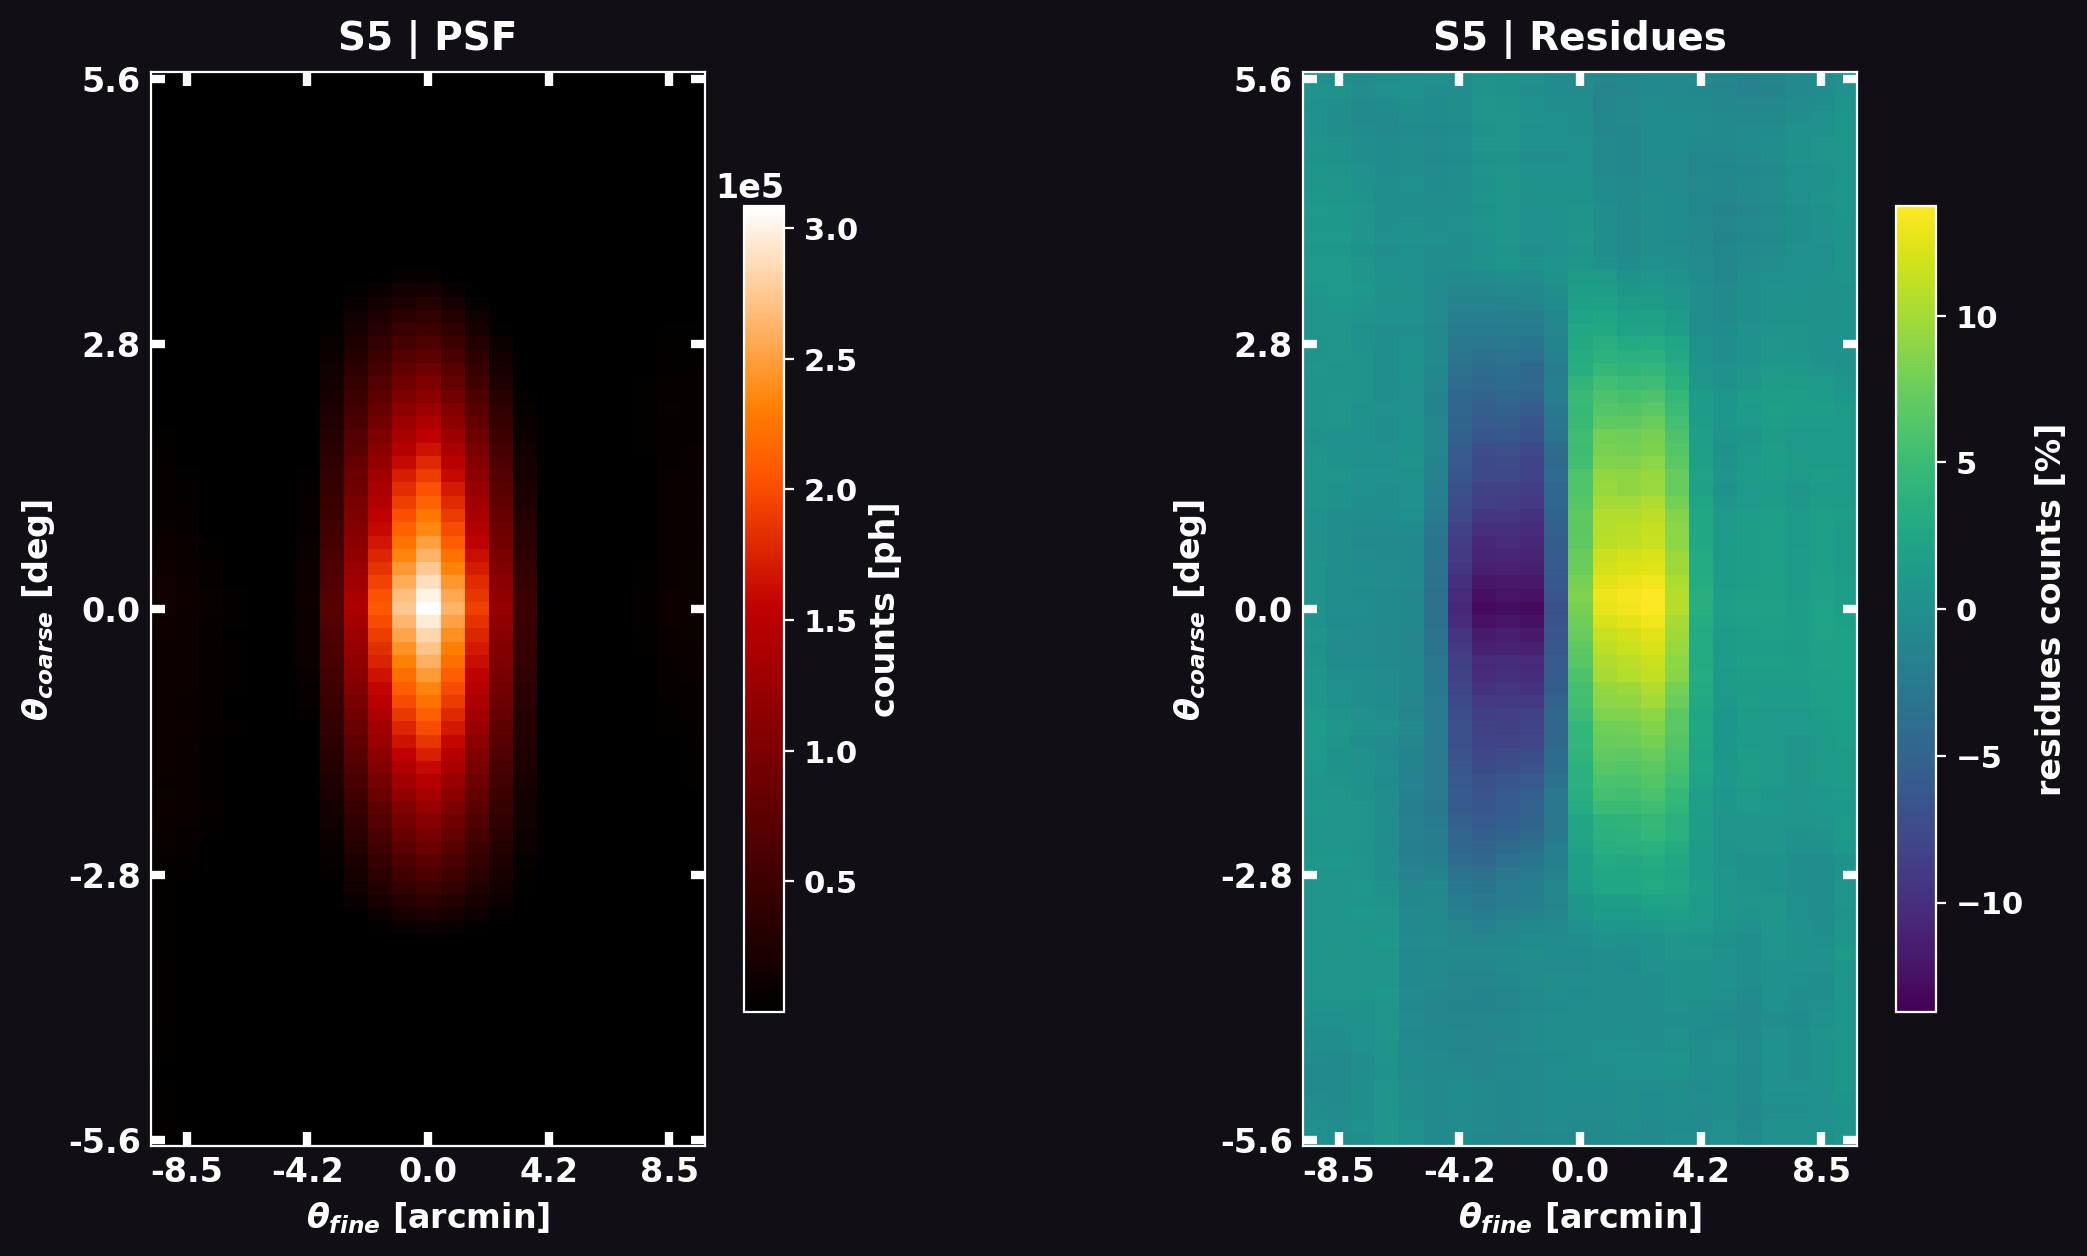

In [ ]:
src_psf, src_res = map(lambda x: ds.crop(x, KWS['pos'], KWS['crp']), (skymap_bline, residues))

n, m = src_psf.shape
yticks, xticks = np.arange(n)[::20], (np.arange(m)[::UPS_X] + 1)[:-1]

custom_PSF_hmap(
    camera=wfm,
    psf=np.clip(src_psf, a_min=1, a_max=src_psf.max()),
    residues=src_res,
    xticks=xticks,
    yticks=yticks,
    title_prefix=KWS['title_prefix'],
    # save_to=f'{OUT_RESULTS_PATH}/psfHM_{E_min}-{E_max}keV.pdf'
)